Import the prerequisite packages

In [21]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torch.distributions as distributions
import numpy as np
import gymnasium as gym  


Check the available environments

In [22]:
import gymnasium as gym
for i in gym.envs.registry.keys():
    print(i)


CartPole-v0
CartPole-v1
MountainCar-v0
MountainCarContinuous-v0
Pendulum-v1
Acrobot-v1
phys2d/CartPole-v0
phys2d/CartPole-v1
phys2d/Pendulum-v0
LunarLander-v3
LunarLanderContinuous-v3
BipedalWalker-v3
BipedalWalkerHardcore-v3
CarRacing-v3
Blackjack-v1
FrozenLake-v1
FrozenLake8x8-v1
CliffWalking-v1
CliffWalkingSlippery-v1
Taxi-v3
tabular/Blackjack-v0
tabular/CliffWalking-v0
Reacher-v2
Reacher-v4
Reacher-v5
Pusher-v2
Pusher-v4
Pusher-v5
InvertedPendulum-v2
InvertedPendulum-v4
InvertedPendulum-v5
InvertedDoublePendulum-v2
InvertedDoublePendulum-v4
InvertedDoublePendulum-v5
HalfCheetah-v2
HalfCheetah-v3
HalfCheetah-v4
HalfCheetah-v5
Hopper-v2
Hopper-v3
Hopper-v4
Hopper-v5
Swimmer-v2
Swimmer-v3
Swimmer-v4
Swimmer-v5
Walker2d-v2
Walker2d-v3
Walker2d-v4
Walker2d-v5
Ant-v2
Ant-v3
Ant-v4
Ant-v5
Humanoid-v2
Humanoid-v3
Humanoid-v4
Humanoid-v5
HumanoidStandup-v2
HumanoidStandup-v4
HumanoidStandup-v5
GymV21Environment-v0
GymV26Environment-v0


Create a new CartPole-v1 environment

In [23]:
import gymnasium as gym
env = gym.make('CartPole-v1')


Check the observation space

In [4]:
print("observation space: ", env.observation_space)

observation space:  Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)


Check an example of an observation

In [5]:
observation, info = env.reset()
print("observation: ", observation)


observation:  [-0.00912775  0.02432707  0.03640049  0.00222201]


Check the action space

In [6]:
print("action space: ", env.action_space)

action space:  Discrete(2)


In [7]:
env = gym.make('CartPole-v1')

Choose a random seed for the training 

In [8]:
SEED = 1234

env.reset(seed=SEED);

In [9]:
np.random.seed(SEED)
torch.manual_seed(SEED)


Create the neural net for the policy

In [10]:
class PolicyNetwork(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, dropout):
        super().__init__()

        self.layer1 = nn.Linear(input_dim, hidden_dim)
        self.layer2 = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.layer1(x)
        x = self.dropout(x)
        x = F.relu(x)
        x = self.layer2(x)
        return x


Write the function to calculate the returns

In [11]:
def calculate_stepwise_returns(rewards, discount_factor):
    returns = []
    R = 0

    for r in reversed(rewards):
        R = r + R * discount_factor
        returns.insert(0, R)
    returns = torch.tensor(returns)
    normalized_returns = (returns - returns.mean()) / returns.std()
    return normalized_returns


Implement the forward pass

In [12]:
def forward_pass(env, policy, discount_factor):
    log_prob_actions = []
    rewards = []
    done = False
    episode_return = 0

    policy.train()
    observation, info = env.reset()

    while not done:
        observation = torch.FloatTensor(observation).unsqueeze(0)
        action_pred = policy(observation)
        action_prob = F.softmax(action_pred, dim = -1)
        dist = distributions.Categorical(action_prob)
        action = dist.sample()
        log_prob_action = dist.log_prob(action)

        observation, reward, terminated, truncated, info = env.step(action.item())
        done = terminated or truncated

        log_prob_actions.append(log_prob_action)
        rewards.append(reward)
        episode_return += reward

    log_prob_actions = torch.cat(log_prob_actions)
    stepwise_returns = calculate_stepwise_returns(rewards, discount_factor)

    return episode_return, stepwise_returns, log_prob_actions


Calculate the loss function as the expected value of the returns

In [13]:
def calculate_loss(stepwise_returns, log_prob_actions):
    loss = -(stepwise_returns * log_prob_actions).sum()
    return loss


Use back propagation to update the policy

In [14]:
def update_policy(stepwise_returns, log_prob_actions, optimizer):
    stepwise_returns = stepwise_returns.detach()
    loss = calculate_loss(stepwise_returns, log_prob_actions)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    return loss.item()



Declare the hyperparameters, run the training epochs, and print the results

In [18]:
def main(): 
    MAX_EPOCHS = 500
    DISCOUNT_FACTOR = 0.99
    N_TRIALS = 25
    REWARD_THRESHOLD = 475
    PRINT_INTERVAL = 10
    INPUT_DIM = env.observation_space.shape[0]
    HIDDEN_DIM = 128
    OUTPUT_DIM = env.action_space.n
    DROPOUT = 0.5

    episode_returns = []

    policy = PolicyNetwork(INPUT_DIM, HIDDEN_DIM, OUTPUT_DIM, DROPOUT)

    LEARNING_RATE = 0.01
    optimizer = optim.Adam(policy.parameters(), lr = LEARNING_RATE)

    for episode in range(1, MAX_EPOCHS+1):
        episode_return, stepwise_returns, log_prob_actions = forward_pass(env, policy, DISCOUNT_FACTOR)
        _ = update_policy(stepwise_returns, log_prob_actions, optimizer)

        episode_returns.append(episode_return)
        mean_episode_return = np.mean(episode_returns[-N_TRIALS:])

        if episode % PRINT_INTERVAL == 0:
            print(f'| Episode: {episode:3} | Mean Rewards: {mean_episode_return:5.1f} |')

        if mean_episode_return >= REWARD_THRESHOLD:
            print(f'Reached reward threshold in {episode} episodes')
            break
    
    return policy


Run the program. 
If the training doesn't converge, run it again, or change the SEED values.

In [19]:
policy = main()

| Episode:  10 | Mean Rewards:  27.1 |
| Episode:  20 | Mean Rewards:  25.0 |
| Episode:  30 | Mean Rewards:  21.6 |
| Episode:  40 | Mean Rewards:  23.3 |
| Episode:  50 | Mean Rewards:  30.5 |
| Episode:  60 | Mean Rewards:  40.0 |
| Episode:  70 | Mean Rewards:  54.0 |
| Episode:  80 | Mean Rewards:  61.7 |
| Episode:  90 | Mean Rewards:  61.3 |
| Episode: 100 | Mean Rewards:  54.7 |
| Episode: 110 | Mean Rewards:  61.4 |
| Episode: 120 | Mean Rewards:  86.0 |
| Episode: 130 | Mean Rewards:  87.6 |
| Episode: 140 | Mean Rewards:  88.5 |
| Episode: 150 | Mean Rewards:  82.8 |
| Episode: 160 | Mean Rewards:  93.8 |
| Episode: 170 | Mean Rewards: 114.6 |
| Episode: 180 | Mean Rewards: 113.8 |
| Episode: 190 | Mean Rewards:  91.4 |
| Episode: 200 | Mean Rewards:  93.1 |
| Episode: 210 | Mean Rewards: 124.0 |
| Episode: 220 | Mean Rewards: 146.4 |
| Episode: 230 | Mean Rewards: 160.5 |
| Episode: 240 | Mean Rewards: 158.1 |
| Episode: 250 | Mean Rewards: 176.9 |
| Episode: 260 | Mean Rew

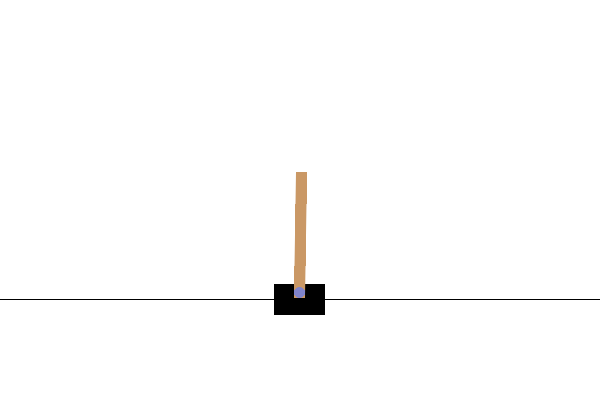

In [24]:
import imageio
from IPython.display import Image, display

render_env = gym.make("CartPole-v1", render_mode="rgb_array")

def record_episode(policy, env, output_path="cartpole.gif"):
    frames = []
    observation, info = env.reset()
    done = False

    while not done:
        frames.append(env.render())
        observation_tensor = torch.FloatTensor(observation).unsqueeze(0)
        action = policy(observation_tensor).argmax().item()
        observation, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

    imageio.mimsave(output_path, frames, fps=30)
    return output_path

gif_path = record_episode(policy, render_env)
display(Image(filename=gif_path))